### Monte Carlo Simulation and Downside Risk Modelling of the S&P 500

How sensitive are simulated S&P 500 downside-risk estimates to assumptions about return distributions and volatility dynamics?

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
!pip install yfinance

# 1. Data Collection and Historical SPY Prices

This project uses approximately 10 years of historical SPY data as a proxy for the S&P 500. Historical closing prices are used to estimate returns and volatility, which are then used as inputs for the simulation models.

In [9]:
import yfinance as yf

In [10]:
spy = yf.download("SPY", start="2016-01-01", end="2026-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [11]:
spy.head()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2016-01-04,169.471573,169.479999,167.422935,169.024753,222353500
2016-01-05,169.758194,170.213440,168.653790,169.791911,110845800
2016-01-06,167.616806,168.662190,166.588274,167.212129,152112600
2016-01-07,163.595428,166.453395,163.207616,164.674542,213436100
2016-01-08,161.799728,165.112954,161.513092,164.556532,209817200


In [12]:
spy.tail()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2025-12-24,686.730530,687.178163,684.164151,684.313382,39445600
2025-12-26,686.660889,688.003728,685.626408,686.989161,41613300
2025-12-29,684.213867,685.556767,682.443308,683.905508,62559500
2025-12-30,683.378296,684.920090,682.950576,683.815972,47160700
2025-12-31,678.315247,683.726492,678.106396,683.507684,74144800


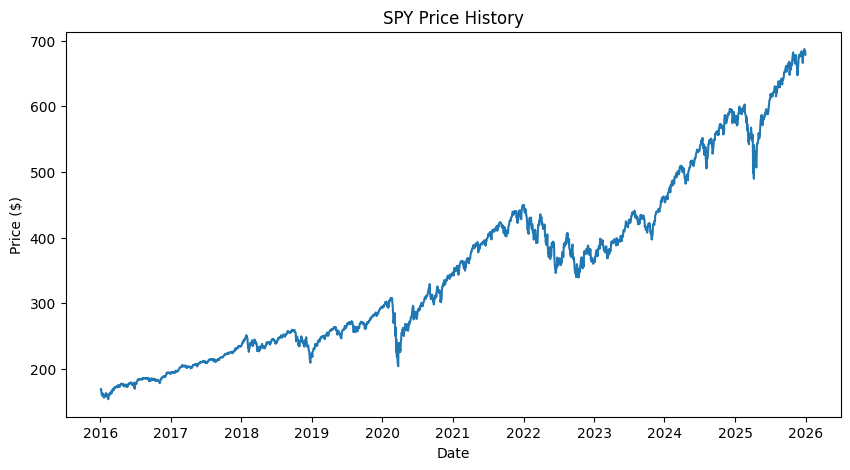

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(spy.index, spy["Close"])
plt.title("SPY Price History")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

In [14]:
close_prices = spy["Close"].squeeze()

# 2. Historical Returns and Volatility

Daily percentage returns are calculated from the historical SPY closing prices. These returns are then used to estimate the average daily return and daily volatility. The daily figures are annualised using approximately 252 trading days per year, giving an estimate of the historical annual return and annualised volatility.

In [15]:
daily_returns = close_prices.pct_change()


In [16]:
daily_returns.head()

,SPY
Date,
2016-01-04,NaN
2016-01-05,0.001691
2016-01-06,-0.012614
2016-01-07,-0.023991
2016-01-08,-0.010976


In [17]:
mean_daily_return = daily_returns.mean()

print(mean_daily_return)


0.0006165530651165794


In [18]:
print(mean_daily_return * 100, "%")

0.06165530651165794 %


In [19]:
daily_volatility = daily_returns.std()

print(daily_volatility * 100, "%")

1.134351440224232 %


In [20]:
annual_return = mean_daily_return * 252
annual_volatility = daily_volatility * np.sqrt(252)

print("Annual return:", annual_return * 100, "%")
print("Annual volatility:", annual_volatility * 100, "%")

Annual return: 15.5371372409378 %
Annual volatility: 18.007270861087612 %


In [21]:
current_price = close_prices.iloc[-1]

print(current_price)

678.3152465820312


In [22]:
trading_days = 252

In [23]:
dt = 1 / trading_days

In [24]:
random_shock = np.random.normal()

print(random_shock)

0.7902301426055182


In [25]:
next_price = current_price * np.exp(
    (annual_return - 0.5 * annual_volatility**2) * dt
    + annual_volatility * np.sqrt(dt) * random_shock
)

print(next_price)

684.8010428960634


In [26]:
prices = [current_price]

In [27]:
for day in range(trading_days):
    random_shock = np.random.normal()

    next_price = prices[-1] * np.exp(
        (annual_return - 0.5 * annual_volatility**2) * dt
        + annual_volatility * np.sqrt(dt) * random_shock
    )

    prices.append(next_price)

In [28]:
len(prices)

253

In [29]:
print("Starting price:", prices[0])
print("Ending price:", prices[-1])

Starting price: 678.3152465820312
Ending price: 808.0091155863382


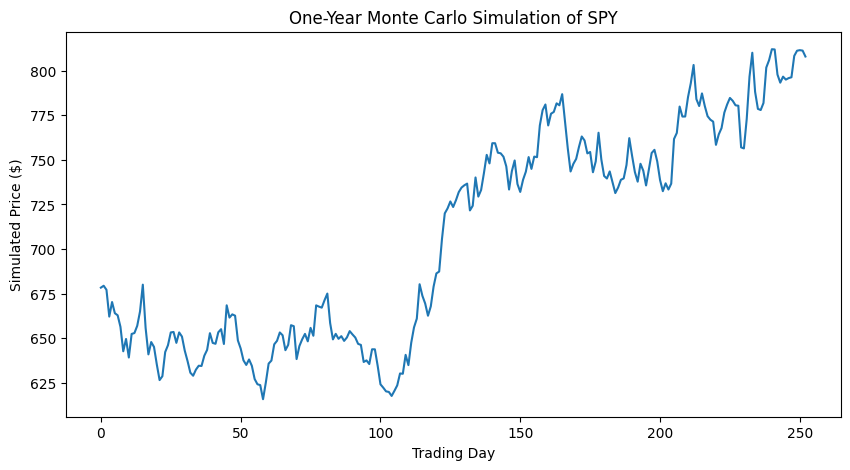

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(prices)

plt.title("One-Year Monte Carlo Simulation of SPY")
plt.xlabel("Trading Day")
plt.ylabel("Simulated Price ($)")

plt.show()

3. Normal GBM Monte Carlo Simulation

---

# New section

The first model uses Geometric Brownian Motion (GBM), which assumes returns follow a constant expected drift and constant volatility, with random shocks drawn from a normal distribution. The model generates 10,000 possible one-year SPY price paths over 252 trading days.

In [31]:
num_simulations = 10000

final_prices = []

In [32]:
for simulation in range(num_simulations):

    price = current_price

    for day in range(trading_days):

        random_shock = np.random.normal()

        price = price * np.exp(
            (annual_return - 0.5 * annual_volatility**2) * dt
            + annual_volatility * np.sqrt(dt) * random_shock
        )

    final_prices.append(price)

In [33]:
len(final_prices)

10000

In [34]:
final_prices[:10]

[np.float64(913.6628008393604),
 np.float64(693.2800128808036),
 np.float64(854.8180275348267),
 np.float64(934.1341396006727),
 np.float64(598.4931717617487),
 np.float64(938.0566172223766),
 np.float64(736.051327983907),
 np.float64(777.4801621709214),
 np.float64(753.498241168408),
 np.float64(1069.672382322032)]

In [35]:
final_prices = np.array(final_prices)

In [36]:
median_final_price = np.median(final_prices)

print("Median final price:", median_final_price)

Median final price: 777.9426223024974


In [37]:
percentile_5 = np.percentile(final_prices, 5)
percentile_95 = np.percentile(final_prices, 95)

print("5th percentile:", percentile_5)
print("95th percentile:", percentile_95)

5th percentile: 580.6628939521652
95th percentile: 1047.1490126185404


In [38]:
probability_lower = np.mean(final_prices < current_price)

print("Probability of finishing below current price:", probability_lower * 100, "%")

Probability of finishing below current price: 22.03 %


In [39]:
twenty_percent_down = current_price * 0.80

In [40]:
probability_20_down = np.mean(final_prices < twenty_percent_down)

print("Probability of a loss greater than 20%:", probability_20_down * 100, "%")

Probability of a loss greater than 20%: 2.06 %


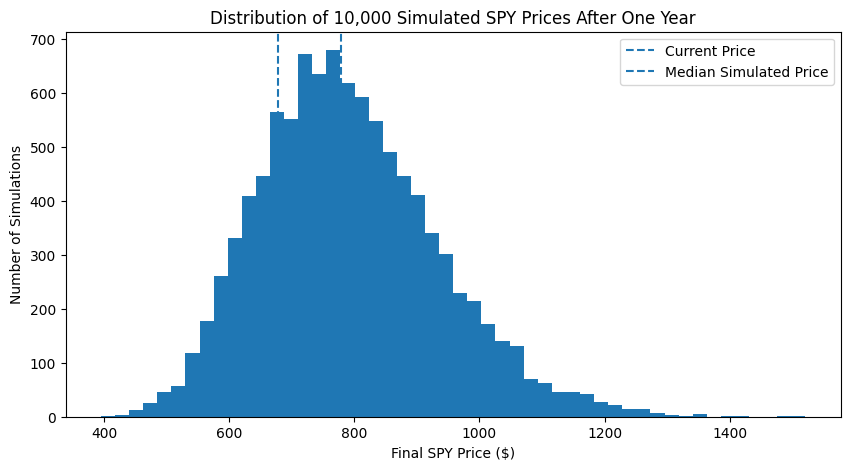

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(final_prices, bins=50)

plt.axvline(current_price, linestyle="--", label="Current Price")
plt.axvline(median_final_price, linestyle="--", label="Median Simulated Price")

plt.title("Distribution of 10,000 Simulated SPY Prices After One Year")
plt.xlabel("Final SPY Price ($)")
plt.ylabel("Number of Simulations")

plt.legend()
plt.show()

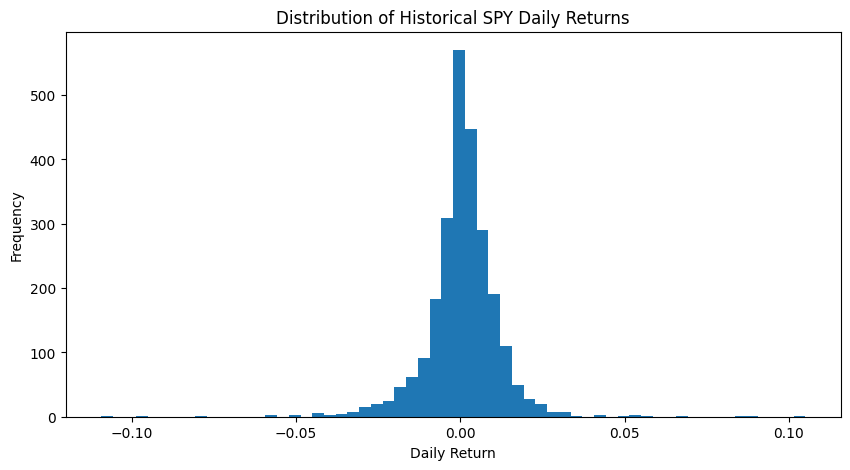

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(daily_returns.dropna(), bins=60)

plt.title("Distribution of Historical SPY Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

# 4. Testing the Normality Assumption

The GBM model assumes normally distributed shocks, so this section tests whether historical SPY log returns are well described by a normal distribution. The historical return distribution is compared with a fitted normal curve, and skewness and excess kurtosis are calculated to assess asymmetry and tail risk.

In [43]:
log_returns = np.log(close_prices / close_prices.shift(1))

log_returns = log_returns.dropna()

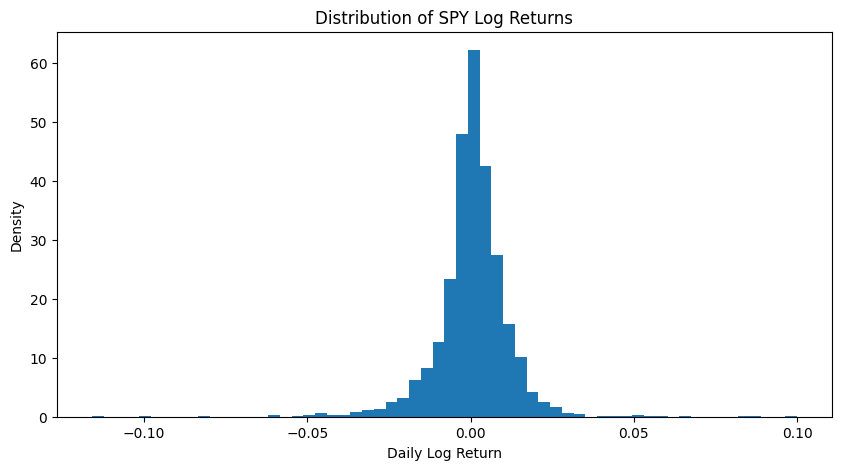

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(log_returns, bins=60, density=True)

plt.title("Distribution of SPY Log Returns")
plt.xlabel("Daily Log Return")
plt.ylabel("Density")

plt.show()

In [45]:
from scipy.stats import norm

In [46]:
x = np.linspace(log_returns.min(), log_returns.max(), 500)

In [47]:
mean_log_return = log_returns.mean()
std_log_return = log_returns.std()

In [48]:
normal_curve = norm.pdf(x, mean_log_return, std_log_return)

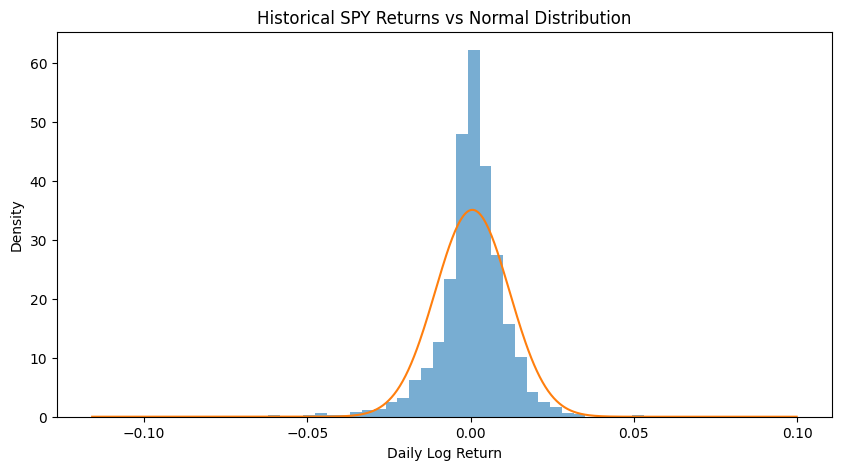

In [49]:
plt.figure(figsize=(10, 5))

plt.hist(log_returns, bins=60, density=True, alpha=0.6)

plt.plot(x, normal_curve)

plt.title("Historical SPY Returns vs Normal Distribution")
plt.xlabel("Daily Log Return")
plt.ylabel("Density")

plt.show()

In [50]:
from scipy.stats import skew, kurtosis

return_skewness = skew(log_returns)
return_kurtosis = kurtosis(log_returns)

print("Skewness:", return_skewness)
print("Excess kurtosis:", return_kurtosis)

Skewness: -0.6044600533765152
Excess kurtosis: 15.121487616593448


In [51]:
num_simulations = 10000
trading_days = 252

simulations = np.zeros((trading_days + 1, num_simulations))

# Every simulation starts at today's price
simulations[0] = current_price

for day in range(1, trading_days + 1):

    random_shocks = np.random.normal(size=num_simulations)

    simulations[day] = simulations[day - 1] * np.exp(
        (annual_return - 0.5 * annual_volatility**2) * dt
        + annual_volatility * np.sqrt(dt) * random_shocks
    )

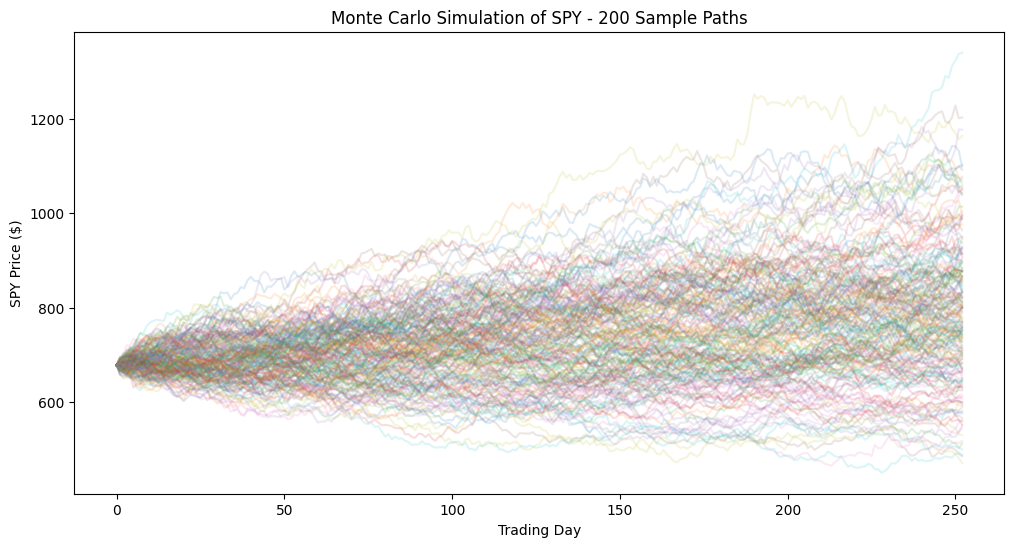

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(simulations[:, :200], alpha=0.15)

plt.title("Monte Carlo Simulation of SPY - 200 Sample Paths")
plt.xlabel("Trading Day")
plt.ylabel("SPY Price ($)")

plt.show()

In [53]:
percentile_5_path = np.percentile(simulations, 5, axis=1)
percentile_25_path = np.percentile(simulations, 25, axis=1)
median_path = np.percentile(simulations, 50, axis=1)
percentile_75_path = np.percentile(simulations, 75, axis=1)
percentile_95_path = np.percentile(simulations, 95, axis=1)

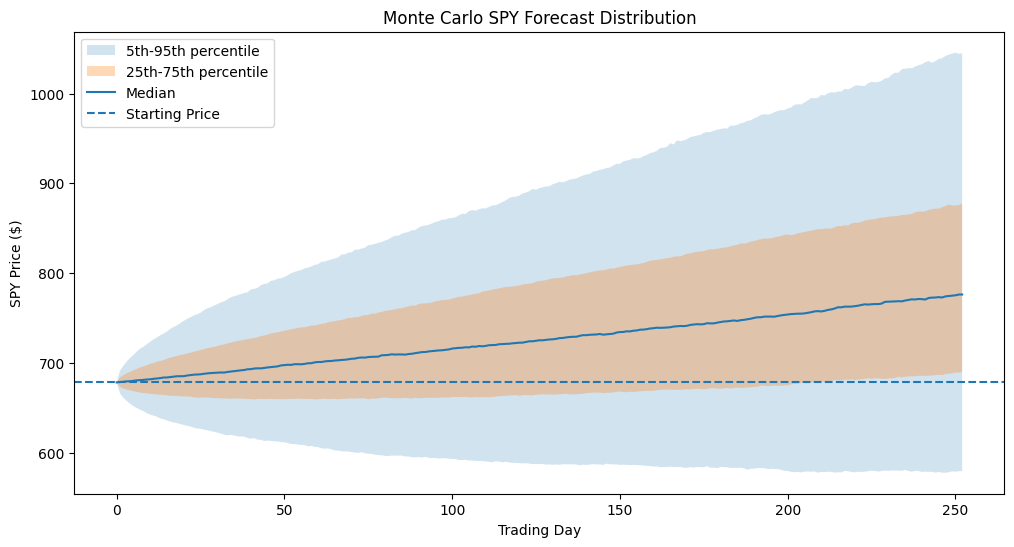

In [54]:
days = np.arange(trading_days + 1)

plt.figure(figsize=(12, 6))

plt.fill_between(
    days,
    percentile_5_path,
    percentile_95_path,
    alpha=0.2,
    label="5th-95th percentile"
)

plt.fill_between(
    days,
    percentile_25_path,
    percentile_75_path,
    alpha=0.3,
    label="25th-75th percentile"
)

plt.plot(days, median_path, label="Median")

plt.axhline(
    current_price,
    linestyle="--",
    label="Starting Price"
)

plt.title("Monte Carlo SPY Forecast Distribution")
plt.xlabel("Trading Day")
plt.ylabel("SPY Price ($)")
plt.legend()

plt.show()

In [55]:
final_prices = simulations[-1]

In [56]:
median_final_price = np.median(final_prices)

percentile_5 = np.percentile(final_prices, 5)
percentile_95 = np.percentile(final_prices, 95)

probability_lower = np.mean(final_prices < current_price)

twenty_percent_down = current_price * 0.80
probability_20_down = np.mean(final_prices < twenty_percent_down)

print("Median final price:", median_final_price)
print("5th percentile:", percentile_5)
print("95th percentile:", percentile_95)
print("Probability of finishing lower:", probability_lower * 100, "%")
print("Probability of losing more than 20%:", probability_20_down * 100, "%")

Median final price: 776.2145893470197
5th percentile: 579.4758346316025
95th percentile: 1044.879768851997
Probability of finishing lower: 22.29 %
Probability of losing more than 20%: 2.33 %


# 5. Student-t Monte Carlo Simulation

Historical SPY returns displayed fat tails, meaning extreme market moves occurred more often than a normal distribution would suggest. This model therefore replaces the normal shocks used in GBM with Student-t shocks, while keeping volatility constant, to test whether heavier-tailed returns materially change downside-risk estimates.

In [57]:
from scipy.stats import t

In [58]:
degrees_of_freedom = 5

t_simulations = np.zeros((trading_days + 1, num_simulations))
t_simulations[0] = current_price

In [59]:
for day in range(1, trading_days + 1):

    random_shocks = t.rvs(
        df=degrees_of_freedom,
        size=num_simulations
    )

    random_shocks = random_shocks / np.sqrt(
        degrees_of_freedom / (degrees_of_freedom - 2)
    )

    t_simulations[day] = t_simulations[day - 1] * np.exp(
        (annual_return - 0.5 * annual_volatility**2) * dt
        + annual_volatility * np.sqrt(dt) * random_shocks
    )

In [60]:
normal_final_prices = simulations[-1]
t_final_prices = t_simulations[-1]

In [61]:
normal_prob_lower = np.mean(normal_final_prices < current_price)
t_prob_lower = np.mean(t_final_prices < current_price)

normal_prob_20_down = np.mean(normal_final_prices < current_price * 0.80)
t_prob_20_down = np.mean(t_final_prices < current_price * 0.80)

print("NORMAL MODEL")
print("Probability of finishing lower:", normal_prob_lower * 100, "%")
print("Probability of losing more than 20%:", normal_prob_20_down * 100, "%")

print()

print("STUDENT-T MODEL")
print("Probability of finishing lower:", t_prob_lower * 100, "%")
print("Probability of losing more than 20%:", t_prob_20_down * 100, "%")

NORMAL MODEL
Probability of finishing lower: 22.29 %
Probability of losing more than 20%: 2.33 %

STUDENT-T MODEL
Probability of finishing lower: 22.03 %
Probability of losing more than 20%: 2.21 %


In [62]:
print("NORMAL 5th percentile:",
      np.percentile(normal_final_prices, 5))

print("STUDENT-T 5th percentile:",
      np.percentile(t_final_prices, 5))

print("NORMAL 1st percentile:",
      np.percentile(normal_final_prices, 1))

print("STUDENT-T 1st percentile:",
      np.percentile(t_final_prices, 1))

NORMAL 5th percentile: 579.4758346316025
STUDENT-T 5th percentile: 581.1439836691322
NORMAL 1st percentile: 510.6075541950659
STUDENT-T 1st percentile: 509.0306685269152


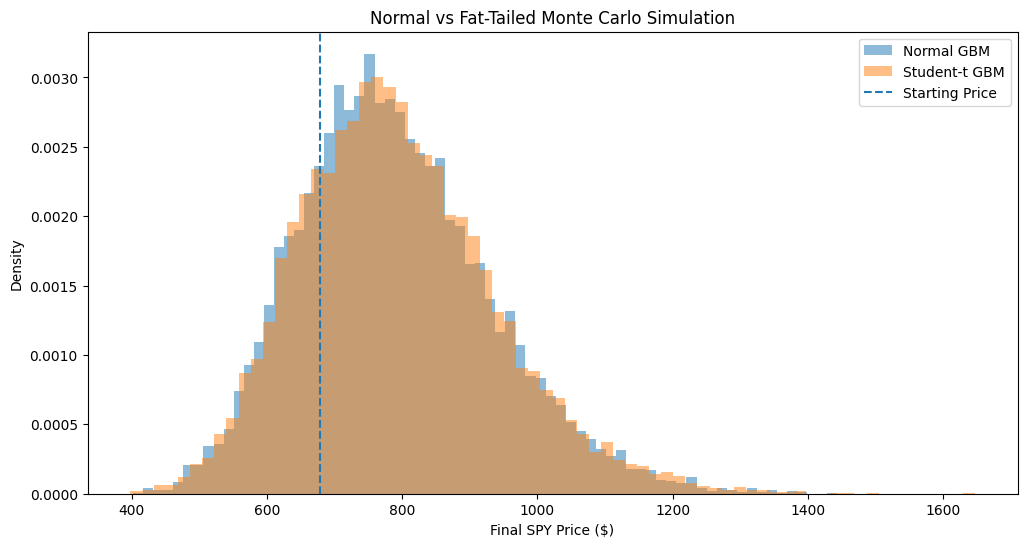

In [63]:
plt.figure(figsize=(12, 6))

plt.hist(
    normal_final_prices,
    bins=70,
    density=True,
    alpha=0.5,
    label="Normal GBM"
)

plt.hist(
    t_final_prices,
    bins=70,
    density=True,
    alpha=0.5,
    label="Student-t GBM"
)

plt.axvline(
    current_price,
    linestyle="--",
    label="Starting Price"
)

plt.title("Normal vs Fat-Tailed Monte Carlo Simulation")
plt.xlabel("Final SPY Price ($)")
plt.ylabel("Density")
plt.legend()

plt.show()

# 6. Maximum Drawdown Analysis

Final-year prices can hide large losses that occur during the year and later recover. Maximum drawdown measures the largest peak-to-trough fall within each simulated path. This section compares the probability of experiencing drawdowns greater than 20% and 30% under the different models.

In [64]:
normal_running_max = np.maximum.accumulate(simulations, axis=0)

t_running_max = np.maximum.accumulate(t_simulations, axis=0)

In [65]:
normal_drawdowns = simulations / normal_running_max - 1

t_drawdowns = t_simulations / t_running_max - 1

In [66]:
normal_max_drawdowns = normal_drawdowns.min(axis=0)

t_max_drawdowns = t_drawdowns.min(axis=0)

In [67]:
normal_20_drawdown = np.mean(normal_max_drawdowns <= -0.20)
t_20_drawdown = np.mean(t_max_drawdowns <= -0.20)

normal_30_drawdown = np.mean(normal_max_drawdowns <= -0.30)
t_30_drawdown = np.mean(t_max_drawdowns <= -0.30)

print("NORMAL MODEL")
print("Probability of 20%+ drawdown:", normal_20_drawdown * 100, "%")
print("Probability of 30%+ drawdown:", normal_30_drawdown * 100, "%")

print()

print("STUDENT-T MODEL")
print("Probability of 20%+ drawdown:", t_20_drawdown * 100, "%")
print("Probability of 30%+ drawdown:", t_30_drawdown * 100, "%")

NORMAL MODEL
Probability of 20%+ drawdown: 17.89 %
Probability of 30%+ drawdown: 1.87 %

STUDENT-T MODEL
Probability of 20%+ drawdown: 16.869999999999997 %
Probability of 30%+ drawdown: 1.82 %


In [68]:
print(
    "Normal median maximum drawdown:",
    np.median(normal_max_drawdowns) * 100,
    "%"
)

print(
    "Student-t median maximum drawdown:",
    np.median(t_max_drawdowns) * 100,
    "%"
)

Normal median maximum drawdown: -13.956824656850758 %
Student-t median maximum drawdown: -13.65519375826843 %


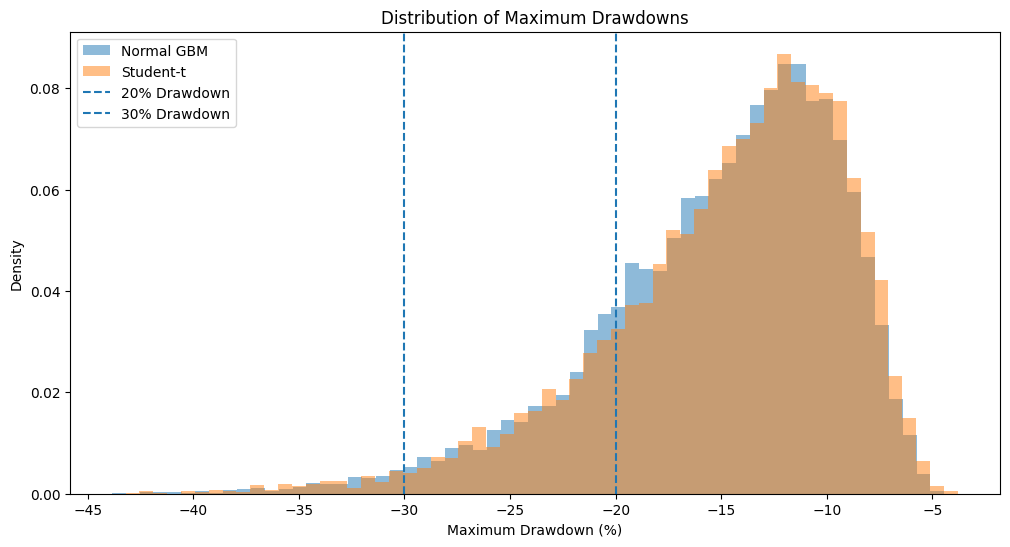

In [69]:
plt.figure(figsize=(12, 6))

plt.hist(
    normal_max_drawdowns * 100,
    bins=60,
    alpha=0.5,
    density=True,
    label="Normal GBM"
)

plt.hist(
    t_max_drawdowns * 100,
    bins=60,
    alpha=0.5,
    density=True,
    label="Student-t"
)

plt.axvline(-20, linestyle="--", label="20% Drawdown")
plt.axvline(-30, linestyle="--", label="30% Drawdown")

plt.title("Distribution of Maximum Drawdowns")
plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Density")

plt.legend()
plt.show()

# 7. GARCH-t Volatility Modelling

Constant-volatility models assume market risk stays the same over time, but real financial markets often exhibit volatility clustering: periods of calm tend to be followed by calm periods, while turbulent periods tend to persist. A GARCH(1,1) model is fitted to historical SPY log returns to estimate time-varying volatility, using Student-t errors to allow for fat-tailed shocks.

In [70]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 30.7 MB/s eta 0:00:00


In [71]:
from arch import arch_model

In [72]:
returns_percent = log_returns * 100

In [73]:
garch_model = arch_model(
    returns_percent,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_result = garch_model.fit(disp="off")

In [74]:
print(garch_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          SPY   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3128.66
Distribution:      Standardized Student's t   AIC:                           6267.32
Method:                  Maximum Likelihood   BIC:                           6296.46
                                              No. Observations:                 2513
Date:                      Sun, Aug 23 2026   Df Residuals:                     2512
Time:                              23:24:09   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

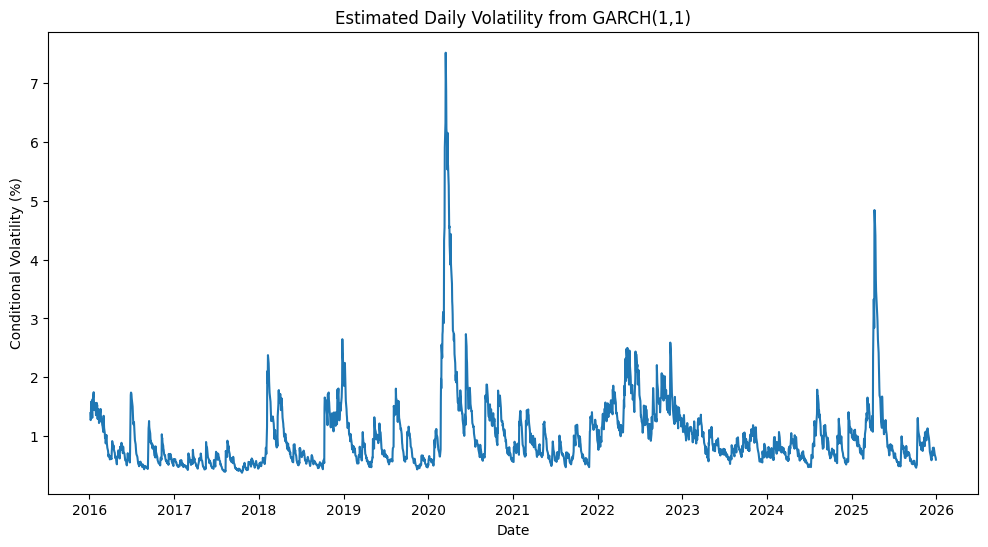

In [75]:
conditional_volatility = garch_result.conditional_volatility

plt.figure(figsize=(12, 6))

plt.plot(conditional_volatility)

plt.title("Estimated Daily Volatility from GARCH(1,1)")
plt.xlabel("Date")
plt.ylabel("Conditional Volatility (%)")

plt.show()

In [76]:
omega = garch_result.params["omega"]
alpha = garch_result.params["alpha[1]"]
beta = garch_result.params["beta[1]"]
nu = garch_result.params["nu"]
mu_garch = garch_result.params["mu"]

print("omega:", omega)
print("alpha:", alpha)
print("beta:", beta)
print("nu:", nu)
print("mu:", mu_garch)

omega: 0.02057450198024805
alpha: 0.17195040123985073
beta: 0.8249007679870116
nu: 5.2277489117387175
mu: 0.10500205242192075


In [77]:
last_volatility = garch_result.conditional_volatility.iloc[-1]
last_residual = garch_result.resid.iloc[-1]

print("Last estimated daily volatility:", last_volatility, "%")
print("Last residual:", last_residual)

Last estimated daily volatility: 0.5968028176876097 %
Last residual: -0.8486455361999755


# 8. GARCH-t Monte Carlo Simulation

The fitted GARCH(1,1) model is used inside a Monte Carlo simulation so that each simulated SPY path has its own evolving volatility process. Unlike the earlier models, volatility can rise after large shocks and remain elevated, allowing the simulation to capture volatility clustering as well as fat-tailed returns.

In [78]:
garch_simulations = np.zeros((trading_days + 1, num_simulations))
garch_volatility = np.zeros((trading_days + 1, num_simulations))

garch_simulations[0] = current_price
garch_volatility[0] = last_volatility

previous_residuals = np.full(
    num_simulations,
    last_residual
)

In [79]:
garch_simulations = np.zeros(
    (trading_days + 1, num_simulations)
)

garch_volatility = np.zeros(
    (trading_days + 1, num_simulations)
)

garch_simulations[0] = current_price
garch_volatility[0] = last_volatility

previous_residuals = np.full(
    num_simulations,
    last_residual
)

for day in range(1, trading_days + 1):

    variance_today = (
        omega
        + alpha * previous_residuals**2
        + beta * garch_volatility[day - 1]**2
    )

    volatility_today = np.sqrt(variance_today)

    garch_volatility[day] = volatility_today

    shocks = t.rvs(
        df=nu,
        size=num_simulations
    )

    shocks = shocks / np.sqrt(
        nu / (nu - 2)
    )

    residual_today = volatility_today * shocks

    daily_return_percent = (
        log_returns.mean() * 100
        + residual_today
    )

    daily_return_decimal = daily_return_percent / 100

    garch_simulations[day] = (
        garch_simulations[day - 1]
        * np.exp(daily_return_decimal)
    )

    previous_residuals = residual_today

In [80]:
print(garch_simulations.shape)
print(garch_volatility.shape)

(253, 10000)
(253, 10000)


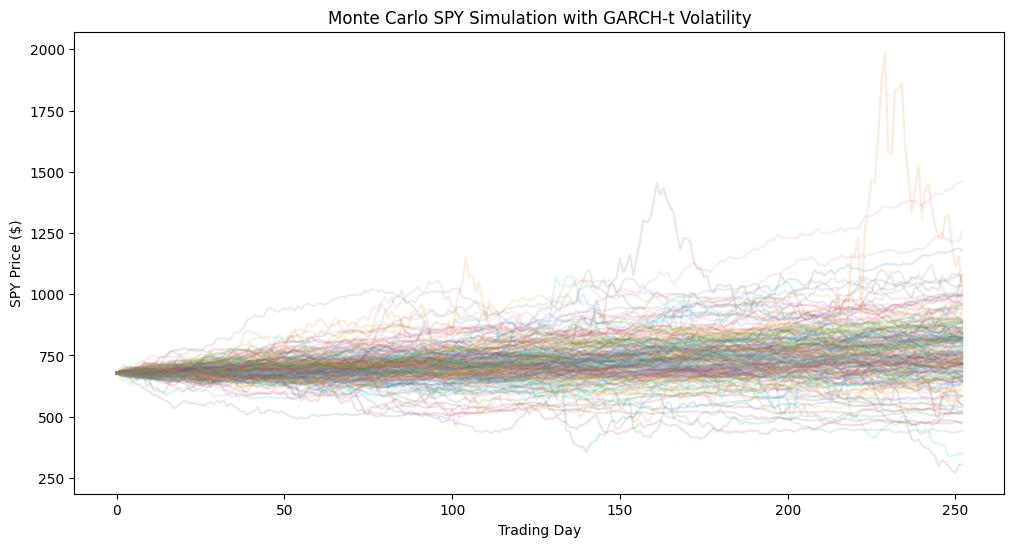

In [81]:
plt.figure(figsize=(12, 6))

plt.plot(
    garch_simulations[:, :200],
    alpha=0.15
)

plt.title("Monte Carlo SPY Simulation with GARCH-t Volatility")
plt.xlabel("Trading Day")
plt.ylabel("SPY Price ($)")

plt.show()

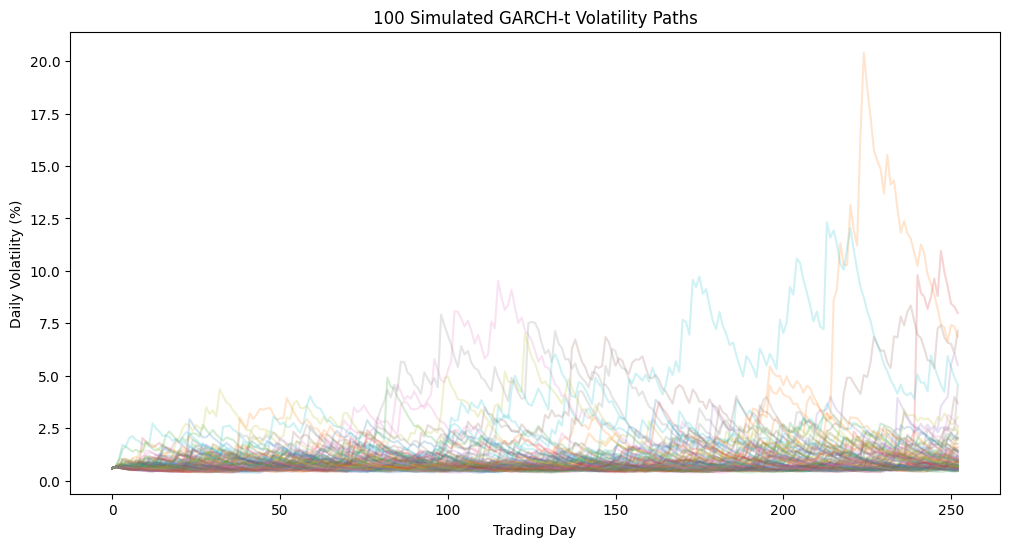

In [82]:
plt.figure(figsize=(12, 6))

plt.plot(
    garch_volatility[:, :100],
    alpha=0.2
)

plt.title("100 Simulated GARCH-t Volatility Paths")
plt.xlabel("Trading Day")
plt.ylabel("Daily Volatility (%)")

plt.show()

In [83]:
garch_running_max = np.maximum.accumulate(
    garch_simulations,
    axis=0
)

garch_drawdowns = (
    garch_simulations / garch_running_max
    - 1
)

garch_max_drawdowns = garch_drawdowns.min(axis=0)

In [84]:
garch_20_drawdown = np.mean(
    garch_max_drawdowns <= -0.20
)

garch_30_drawdown = np.mean(
    garch_max_drawdowns <= -0.30
)

garch_median_drawdown = np.median(
    garch_max_drawdowns
)

print("GARCH-t MODEL")
print("20%+ drawdown:", garch_20_drawdown * 100, "%")
print("30%+ drawdown:", garch_30_drawdown * 100, "%")
print("Median max drawdown:", garch_median_drawdown * 100, "%")

GARCH-t MODEL
20%+ drawdown: 18.0 %
30%+ drawdown: 7.02 %
Median max drawdown: -11.013385709657392 %


# 9. Model Comparison

The three models are compared using maximum drawdown statistics. This allows the effect of different modelling assumptions to be evaluated directly: Normal GBM assumes constant volatility and normal shocks, Student-t GBM keeps volatility constant but allows fatter-tailed shocks, and GARCH-t allows both fat-tailed shocks and time-varying volatility.

In [85]:
print("NORMAL GBM")
print("20%+ drawdown:", normal_20_drawdown * 100, "%")
print("30%+ drawdown:", normal_30_drawdown * 100, "%")
print(
    "Median max drawdown:",
    np.median(normal_max_drawdowns) * 100,
    "%"
)

print()

print("STUDENT-T GBM")
print("20%+ drawdown:", t_20_drawdown * 100, "%")
print("30%+ drawdown:", t_30_drawdown * 100, "%")
print(
    "Median max drawdown:",
    np.median(t_max_drawdowns) * 100,
    "%"
)

print()

print("GARCH-T")
print("20%+ drawdown:", garch_20_drawdown * 100, "%")
print("30%+ drawdown:", garch_30_drawdown * 100, "%")
print(
    "Median max drawdown:",
    garch_median_drawdown * 100,
    "%"
)

NORMAL GBM
20%+ drawdown: 17.89 %
30%+ drawdown: 1.87 %
Median max drawdown: -13.956824656850758 %

STUDENT-T GBM
20%+ drawdown: 16.869999999999997 %
30%+ drawdown: 1.82 %
Median max drawdown: -13.65519375826843 %

GARCH-T
20%+ drawdown: 18.0 %
30%+ drawdown: 7.02 %
Median max drawdown: -11.013385709657392 %


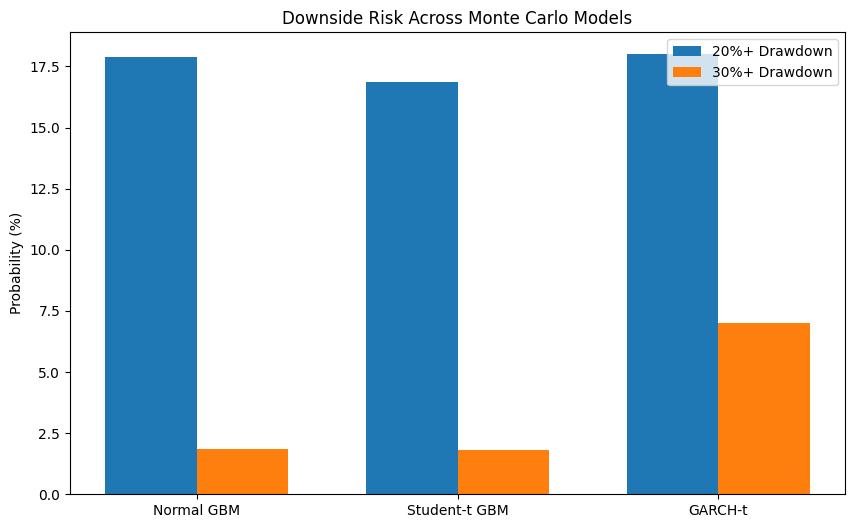

In [86]:
models = ["Normal GBM", "Student-t GBM", "GARCH-t"]

drawdown_20 = [
    normal_20_drawdown * 100,
    t_20_drawdown * 100,
    garch_20_drawdown * 100
]

drawdown_30 = [
    normal_30_drawdown * 100,
    t_30_drawdown * 100,
    garch_30_drawdown * 100
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    drawdown_20,
    width,
    label="20%+ Drawdown"
)

plt.bar(
    x + width/2,
    drawdown_30,
    width,
    label="30%+ Drawdown"
)

plt.xticks(x, models)
plt.ylabel("Probability (%)")
plt.title("Downside Risk Across Monte Carlo Models")

plt.legend()
plt.show()

In [87]:
results_table = pd.DataFrame({
    "Model": [
        "Normal GBM",
        "Student-t GBM",
        "GARCH-t"
    ],
    "20%+ Drawdown Probability (%)": [
        normal_20_drawdown * 100,
        t_20_drawdown * 100,
        garch_20_drawdown * 100
    ],
    "30%+ Drawdown Probability (%)": [
        normal_30_drawdown * 100,
        t_30_drawdown * 100,
        garch_30_drawdown * 100
    ],
    "Median Maximum Drawdown (%)": [
        np.median(normal_max_drawdowns) * 100,
        np.median(t_max_drawdowns) * 100,
        garch_median_drawdown * 100
    ]
})

results_table.round(2)

,Model,20%+ Drawdown Probability (%),30%+ Drawdown Probability (%),Median Maximum Drawdown (%)
0,Normal GBM,17.89,1.87,-13.96
1,Student-t GBM,16.87,1.82,-13.66
2,GARCH-t,18.00,7.02,-11.01


Key results:

Normal GBM: 20%+ drawdown probability = 17.74%; 30%+ drawdown probability = 1.70%

Student-t GBM: 20%+ drawdown probability = 16.53%; 30%+ drawdown probability = 1.75%

GARCH-t: 20%+ drawdown probability = 17.53%; 30%+ drawdown probability = 6.59%

The largest difference appears in the extreme tail: the GARCH-t model produces a much higher simulated probability of a 30%+ drawdown.

The comparison chart above visualises the difference in simulated 20%+ and 30%+ drawdown probabilities across the three models.

# 10. Conclusion and Limitations

The results suggest that moderate downside-risk estimates are relatively similar across the three models, but extreme tail-risk estimates are much more sensitive to volatility assumptions. The GARCH-t model, in particular produced a substantially higher probability of 30%+ drawdowns than the constant volatility models, highlighting the importance of volatility clustering in extreme market scenarios.

The models remain simplified representations of real financial markets. They are calibrated using historical SPY data and do not account for structural breaks, changing economic regimes, jumps, liquidity effects or other market factors. The simulated probabilities should therefore be interpreted as model-dependent estimates rather than forecasts of future market outcomes.